# SLT Call Center Dataset - PROCLUS-inspired projected clustering analysis

## Objective
This notebook applies a **PROCLUS-inspired projected clustering approach** to identify the feature subspaces that best define:

- `queue_time`
- `talk_time`

PROCLUS (Projected Clustering) assigns each cluster its own relevant subspace, rather than finding one global subspace for all clusters. This allows different caller segments to be described by the features that matter most for that specific group.

> Note: This is a PROCLUS-inspired implementation built from scratch. The original PROCLUS algorithm (Aggarwal et al., 1999) is not available as a standard Python library. The core logic — medoid-based cluster seeding, per-cluster subspace selection by variance, and iterative reassignment — is implemented here to follow the PROCLUS methodology as closely as possible on this dataset.

The candidate subspaces used here are informed by the SUBCLU analysis results:
- **Queue Time:** `[subOption, IVRPosition, enteredQueue]` emerged as the strongest business subspace
- **Talk Time:** `[lang, validAccount, selectedQueue]` emerged as the strongest business subspace

PROCLUS builds on these by allowing each cluster to independently determine which subset of features it clusters on.

In [1]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

In [2]:
# ===============================
# 2. LOAD DATASET
# ===============================

from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/SLT_PROJECT/5000.csv"
df = pd.read_csv(FILE_PATH)

Mounted at /content/drive


In [3]:
# ===============================
# 3. SELECT FEATURES AND TARGETS
# ===============================

features = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue',
    'isAnswered'
]

features_without_answered = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue'
]

targets = ['queue_time', 'talk_time']

# Candidate subspaces drawn from SUBCLU top results
# These are used as dimension pools for PROCLUS subspace selection
QUEUE_CANDIDATE_DIMS = ['subOption', 'IVRPosition', 'enteredQueue', 'lang', 'selectedQueue', 'mainOption', 'suspendedAsset']
TALK_CANDIDATE_DIMS  = ['lang', 'validAccount', 'selectedQueue', 'enteredQueue', 'IVRPosition', 'mainOption', 'subOption']

print("Total features (with isAnswered):", len(features))
print("Features without isAnswered:", len(features_without_answered))
print("Targets:", targets)

Total features (with isAnswered): 13
Features without isAnswered: 12
Targets: ['queue_time', 'talk_time']


In [4]:
# ===============================
# 4. DATA CLEANING
# ===============================

df = df.copy()

# Convert target variables to numeric
df['queue_time'] = pd.to_numeric(df['queue_time'], errors='coerce')
df['talk_time']  = pd.to_numeric(df['talk_time'],  errors='coerce')

# Fill missing feature values before encoding
for col in features:
    df[col] = df[col].fillna('Unknown').astype(str)

# Drop rows where either target is missing
df = df.dropna(subset=['queue_time', 'talk_time'])

# Non-zero subset — calls that actually entered the queue and connected to an agent
df_nonzero = df[(df['queue_time'] > 0) & (df['talk_time'] > 0)].copy()

print("Full dataset shape:", df.shape)
print("Non-zero queue_time AND talk_time:", df_nonzero.shape)
print("Records with zero values:", df.shape[0] - df_nonzero.shape[0])

Full dataset shape: (5000, 17)
Non-zero queue_time AND talk_time: (768, 17)
Records with zero values: 4232


In [5]:
# ===============================
# 5. ENCODE CATEGORICAL FEATURES
# ===============================

def encode_features(input_df, feature_list):
    encoded = input_df[feature_list].copy()
    encoders = {}

    for col in feature_list:
        le = LabelEncoder()
        encoded[col] = le.fit_transform(encoded[col].astype(str))
        encoders[col] = le

    return encoded, encoders

# Full dataset — with and without isAnswered
encoded_df,          label_encoders          = encode_features(df,          features)
encoded_df_no_ans,   label_encoders_no_ans   = encode_features(df,          features_without_answered)

# Non-zero dataset
encoded_nonzero,     label_encoders_nonzero  = encode_features(df_nonzero,  features_without_answered)

display(encoded_df.head())

,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered
0,1,2,1,80,0,0,0,0,1,1880,17,1,1
1,1,5,4,64,0,0,0,0,1,1071,12,0,0
2,1,0,1,47,0,0,0,0,1,387,9,1,1
3,1,0,1,81,0,0,0,0,0,2234,9,1,0
4,1,8,1,46,0,0,0,0,0,2234,26,0,0


## PROCLUS Algorithm — Implementation

PROCLUS works in three phases:

1. **Initialisation** — Select a set of candidate medoids from the data. A medoid is the actual data point that sits closest to the centre of its cluster (unlike a centroid, which is just the mean and may not correspond to any real point).

2. **Iteration** — For each medoid, identify its *relevant dimensions*: the features where the data points near that medoid are tightly packed (low variance). Assign every point to the nearest medoid using only that medoid's relevant dimensions.

3. **Refinement** — Swap out poorly performing medoids and repeat until the cluster assignments stabilise.

The result is a set of clusters, each described by its own subset of features — which is the key difference from standard k-means or DBSCAN.

In [6]:
# ===============================
# 6. PROCLUS CORE IMPLEMENTATION
# ===============================

def select_medoids(X, k, random_state=42):
    """
    Sample a set of candidate medoids from the scaled data.
    Returns k row indices.
    """
    np.random.seed(random_state)
    n = X.shape[0]
    # Use a larger candidate pool then trim to k — mirrors the PROCLUS init step
    candidate_pool = min(n, k * 4)
    candidates = np.random.choice(n, size=candidate_pool, replace=False)

    selected = [candidates[0]]
    for _ in range(k - 1):
        # Greedily pick the candidate furthest from already-selected medoids
        dists = cdist(X[candidates], X[selected]).min(axis=1)
        next_idx = candidates[np.argmax(dists)]
        selected.append(next_idx)

    return selected


def find_relevant_dims(X, medoid_idx, all_assigned_idx, l):
    """
    For a given medoid, find the l dimensions with the lowest variance
    among the points currently assigned to it.
    Low variance = the cluster is tightly packed in that dimension = relevant.
    """
    if len(all_assigned_idx) == 0:
        return list(range(min(l, X.shape[1])))

    subset = X[all_assigned_idx]
    variances = subset.var(axis=0)
    # Sort ascending — lowest variance features are most relevant
    sorted_dims = np.argsort(variances)
    return sorted_dims[:l].tolist()


def assign_points(X, medoids, cluster_dims):
    """
    Assign each point to its nearest medoid.
    Distance is computed only on that medoid's relevant dimensions.
    """
    n = X.shape[0]
    labels = np.full(n, -1, dtype=int)
    min_dists = np.full(n, np.inf)

    for cluster_id, medoid_idx in enumerate(medoids):
        dims = cluster_dims[cluster_id]
        if len(dims) == 0:
            continue
        diff = X[:, dims] - X[medoid_idx, dims]
        dists = np.linalg.norm(diff, axis=1)
        better = dists < min_dists
        labels[better] = cluster_id
        min_dists[better] = dists[better]

    return labels


def proclus(
    X,
    k=5,
    l=3,
    max_iter=20,
    random_state=42
):
    """
    PROCLUS-inspired projected clustering.

    Parameters
    ----------
    X            : scaled numpy array, shape (n_samples, n_features)
    k            : number of clusters
    l            : average number of relevant dimensions per cluster
    max_iter     : maximum refinement iterations
    random_state : seed for reproducibility

    Returns
    -------
    labels       : cluster label per point (-1 = unassigned)
    medoids      : final medoid indices
    cluster_dims : list of relevant dimension indices per cluster
    """
    n, d = X.shape

    # -- Phase 1: Initialisation --
    medoids = select_medoids(X, k, random_state=random_state)

    # Start with all dimensions equally weighted for the first pass
    cluster_dims = [list(range(d)) for _ in range(k)]

    labels = assign_points(X, medoids, cluster_dims)

    prev_labels = None

    # -- Phase 2 & 3: Iteration and Refinement --
    for iteration in range(max_iter):

        # Update relevant dimensions for each cluster based on current assignments
        new_cluster_dims = []
        new_medoids = []

        for cluster_id in range(k):
            assigned_idx = np.where(labels == cluster_id)[0]

            if len(assigned_idx) < 2:
                # Empty or singleton cluster — keep the old medoid, use all dims
                new_cluster_dims.append(list(range(min(l, d))))
                new_medoids.append(medoids[cluster_id])
                continue

            # Relevant dimensions: lowest variance within this cluster
            dims = find_relevant_dims(X, medoids[cluster_id], assigned_idx, l)
            new_cluster_dims.append(dims)

            # Re-select medoid: the point in this cluster closest to its own mean
            # (on the relevant dimensions only)
            subset = X[assigned_idx][:, dims]
            centroid = subset.mean(axis=0)
            dists_to_centroid = np.linalg.norm(subset - centroid, axis=1)
            new_medoid_local = np.argmin(dists_to_centroid)
            new_medoids.append(assigned_idx[new_medoid_local])

        medoids = new_medoids
        cluster_dims = new_cluster_dims

        # Reassign all points
        labels = assign_points(X, medoids, cluster_dims)

        # Check for convergence
        if prev_labels is not None and np.array_equal(labels, prev_labels):
            print(f"  Converged at iteration {iteration + 1}")
            break

        prev_labels = labels.copy()

    return labels, medoids, cluster_dims

In [7]:
# ===============================
# 7. PROCLUS ANALYSIS FUNCTION
# ===============================

def run_proclus_analysis(
    encoded_data,
    original_data,
    feature_list,
    target,
    k_values,
    l_values,
    min_cluster_size=30,
    max_iter=20,
    random_state=42
):
    """
    Runs PROCLUS over a grid of (k, l) combinations and returns
    a ranked results table.

    k : number of clusters
    l : average relevant dimensions per cluster
    """
    X_raw = encoded_data[feature_list].values
    X_scaled = StandardScaler().fit_transform(X_raw)
    feature_arr = np.array(feature_list)

    results = []

    for k in k_values:
        for l in l_values:
            if l > len(feature_list):
                continue

            labels, medoids, cluster_dims = proclus(
                X_scaled, k=k, l=l, max_iter=max_iter, random_state=random_state
            )

            temp = original_data.copy()
            temp['Cluster'] = labels

            unique_labels = [lb for lb in set(labels) if lb != -1]
            noise_count  = list(labels).count(-1)
            noise_ratio  = noise_count / len(labels)

            cluster_summary = temp.groupby('Cluster')[target].agg(
                ['count', 'mean']
            ).reset_index()
            cluster_summary = cluster_summary[cluster_summary['Cluster'] != -1]
            valid_clusters  = cluster_summary[cluster_summary['count'] >= min_cluster_size]

            if len(valid_clusters) >= 2:
                highest_mean = valid_clusters['mean'].max()
                lowest_mean  = valid_clusters['mean'].min()
                separation   = highest_mean - lowest_mean
            else:
                highest_mean = 0
                lowest_mean  = 0
                separation   = 0

            quality_score = separation * (1 - noise_ratio)

            # Collect per-cluster subspace names for reporting
            cluster_subspaces = {
                f"Cluster_{cid}": list(feature_arr[cluster_dims[cid]])
                for cid in range(k)
            }

            # Silhouette score requires at least 2 clusters with >1 member
            try:
                sil = silhouette_score(X_scaled, labels) if len(set(labels)) > 1 else -1
            except Exception:
                sil = -1

            results.append({
                'k':              k,
                'l':              l,
                'Target':         target,
                'Clusters_Found': len(unique_labels),
                'Separation':     round(separation,   2),
                'Quality_Score':  round(quality_score, 2),
                'Silhouette':     round(sil,           4),
                'Noise_Count':    noise_count,
                'Noise_Ratio':    round(noise_ratio,   4),
                'Highest_Mean':   round(highest_mean,  2),
                'Lowest_Mean':    round(lowest_mean,   2),
                'Cluster_Subspaces': cluster_subspaces
            })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Quality_Score', ascending=False).reset_index(drop=True)

    return results_df

## Analysis 1 — PROCLUS With `isAnswered`

This analysis includes `isAnswered` in the feature pool. As seen in SUBCLU, this feature tends to dominate separation by splitting answered vs. unanswered calls. Results here are included for completeness and comparison.

In [8]:
# ===============================
# 8. RUN ANALYSIS WITH isAnswered
# ===============================

# Grid search over k (number of clusters) and l (avg dims per cluster)
K_VALUES = [4, 6, 8, 10, 12]
L_VALUES = [2, 3, 4]

print("Running PROCLUS — Queue Time WITH isAnswered...")
queue_results_with_ans = run_proclus_analysis(
    encoded_data=encoded_df,
    original_data=df,
    feature_list=features,
    target='queue_time',
    k_values=K_VALUES,
    l_values=L_VALUES,
    min_cluster_size=30
)

print("Running PROCLUS — Talk Time WITH isAnswered...")
talk_results_with_ans = run_proclus_analysis(
    encoded_data=encoded_df,
    original_data=df,
    feature_list=features,
    target='talk_time',
    k_values=K_VALUES,
    l_values=L_VALUES,
    min_cluster_size=30
)

print("\nTop 10 Queue Time results WITH isAnswered")
display(queue_results_with_ans.drop(columns=['Cluster_Subspaces']).head(10))

print("\nTop 10 Talk Time results WITH isAnswered")
display(talk_results_with_ans.drop(columns=['Cluster_Subspaces']).head(10))

Running PROCLUS — Queue Time WITH isAnswered...
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
Running PROCLUS — Talk Time WITH isAnswered...
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2

Top 10 Queue Time results WITH isAnswered


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,10,4,queue_time,6,797.97,797.97,0.2281,0,0.0,797.97,0.0
1,8,3,queue_time,4,698.01,698.01,0.1579,0,0.0,698.01,0.0
2,6,3,queue_time,4,698.01,698.01,0.1579,0,0.0,698.01,0.0
3,10,3,queue_time,4,698.01,698.01,0.1579,0,0.0,698.01,0.0
4,8,2,queue_time,3,666.16,666.16,0.2101,0,0.0,666.16,0.0
5,6,2,queue_time,3,666.16,666.16,0.2101,0,0.0,666.16,0.0
6,4,2,queue_time,3,666.16,666.16,0.2101,0,0.0,666.16,0.0
7,6,4,queue_time,5,248.96,248.96,0.2314,0,0.0,248.96,0.0
8,8,4,queue_time,5,233.19,233.19,0.2404,0,0.0,233.19,0.0
9,4,4,queue_time,4,225.91,225.91,0.1766,0,0.0,225.91,0.0



Top 10 Talk Time results WITH isAnswered


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,6,3,talk_time,4,135.22,135.22,0.1579,0,0.0,135.22,0.00
1,10,3,talk_time,4,135.22,135.22,0.1579,0,0.0,135.22,0.00
2,8,3,talk_time,4,135.22,135.22,0.1579,0,0.0,135.22,0.00
3,8,2,talk_time,3,108.52,108.52,0.2101,0,0.0,108.52,0.00
4,4,2,talk_time,3,108.52,108.52,0.2101,0,0.0,108.52,0.00
5,6,2,talk_time,3,108.52,108.52,0.2101,0,0.0,108.52,0.00
6,10,4,talk_time,6,105.99,105.99,0.2281,0,0.0,105.99,0.00
7,8,4,talk_time,5,55.81,55.81,0.2404,0,0.0,55.81,0.00
8,12,4,talk_time,5,41.49,41.49,0.2480,0,0.0,46.51,5.02
9,4,3,talk_time,3,40.24,40.24,0.2239,0,0.0,40.24,0.00


## Analysis 2 — PROCLUS Without `isAnswered` (Recommended)

Removing `isAnswered` forces PROCLUS to discover clusters based on genuine operational features — IVR navigation paths, language, account status, and queue routing. This produces actionable results that the operations team can act on.

In [9]:
# ===============================
# 9. RUN ANALYSIS WITHOUT isAnswered
# ===============================

print("Running PROCLUS — Queue Time WITHOUT isAnswered...")
queue_results_no_ans = run_proclus_analysis(
    encoded_data=encoded_df_no_ans,
    original_data=df,
    feature_list=features_without_answered,
    target='queue_time',
    k_values=K_VALUES,
    l_values=L_VALUES,
    min_cluster_size=30
)

print("Running PROCLUS — Talk Time WITHOUT isAnswered...")
talk_results_no_ans = run_proclus_analysis(
    encoded_data=encoded_df_no_ans,
    original_data=df,
    feature_list=features_without_answered,
    target='talk_time',
    k_values=K_VALUES,
    l_values=L_VALUES,
    min_cluster_size=30
)

print("\nTop 10 Queue Time results WITHOUT isAnswered")
display(queue_results_no_ans.drop(columns=['Cluster_Subspaces']).head(10))

print("\nTop 10 Talk Time results WITHOUT isAnswered")
display(talk_results_no_ans.drop(columns=['Cluster_Subspaces']).head(10))

Running PROCLUS — Queue Time WITHOUT isAnswered...
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
Running PROCLUS — Talk Time WITHOUT isAnswered...
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 4
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2

Top 10 Queue Time results WITHOUT isAnswered


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,10,4,queue_time,5,235.90,235.90,0.2920,0,0.0,235.90,0.00
1,8,4,queue_time,4,226.98,226.98,0.2810,0,0.0,226.98,0.00
2,6,4,queue_time,4,226.98,226.98,0.2810,0,0.0,226.98,0.00
3,8,3,queue_time,4,205.86,205.86,0.2637,0,0.0,235.90,30.05
4,10,3,queue_time,4,205.86,205.86,0.2637,0,0.0,235.90,30.05
5,6,3,queue_time,4,205.86,205.86,0.2637,0,0.0,235.90,30.05
6,12,3,queue_time,4,196.90,196.90,0.3365,0,0.0,221.93,25.03
7,4,3,queue_time,3,195.23,195.23,0.3486,0,0.0,221.93,26.70
8,12,4,queue_time,5,194.35,194.35,0.2846,0,0.0,226.40,32.05
9,4,4,queue_time,4,159.63,159.63,0.2711,0,0.0,187.61,27.98



Top 10 Talk Time results WITHOUT isAnswered


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,10,4,talk_time,5,56.48,56.48,0.2920,0,0.0,56.48,0.00
1,8,3,talk_time,4,51.77,51.77,0.2637,0,0.0,56.48,4.70
2,6,3,talk_time,4,51.77,51.77,0.2637,0,0.0,56.48,4.70
3,10,3,talk_time,4,51.77,51.77,0.2637,0,0.0,56.48,4.70
4,12,4,talk_time,5,41.49,41.49,0.2846,0,0.0,46.51,5.02
5,6,4,talk_time,4,31.69,31.69,0.2810,0,0.0,31.69,0.00
6,8,4,talk_time,4,31.69,31.69,0.2810,0,0.0,31.69,0.00
7,12,2,talk_time,3,27.95,27.95,0.4592,0,0.0,46.51,18.56
8,12,3,talk_time,4,26.03,26.03,0.3365,0,0.0,31.05,5.02
9,4,3,talk_time,3,23.78,23.78,0.3486,0,0.0,31.05,7.26


## Analysis 3 — Non-Zero Records (Active Calls Only)

This analysis uses only the records where both `queue_time > 0` and `talk_time > 0`, representing calls that genuinely entered the queue and connected to an agent. This removes the distortion from the large volume of unanswered/zero-time calls and focuses PROCLUS on real call behaviour.

In [10]:
# ===============================
# 10. RUN ANALYSIS ON NON-ZERO DATA
# ===============================

# Smaller dataset — reduce k range slightly so clusters remain meaningful
K_VALUES_NZ = [3, 4, 5, 6, 8]

print("Running PROCLUS — Queue Time on NON-ZERO records...")
queue_results_nz = run_proclus_analysis(
    encoded_data=encoded_nonzero,
    original_data=df_nonzero,
    feature_list=features_without_answered,
    target='queue_time',
    k_values=K_VALUES_NZ,
    l_values=L_VALUES,
    min_cluster_size=15
)

print("Running PROCLUS — Talk Time on NON-ZERO records...")
talk_results_nz = run_proclus_analysis(
    encoded_data=encoded_nonzero,
    original_data=df_nonzero,
    feature_list=features_without_answered,
    target='talk_time',
    k_values=K_VALUES_NZ,
    l_values=L_VALUES,
    min_cluster_size=15
)

print("\nTop 10 Queue Time results on NON-ZERO data")
display(queue_results_nz.drop(columns=['Cluster_Subspaces']).head(10))

print("\nTop 10 Talk Time results on NON-ZERO data")
display(talk_results_nz.drop(columns=['Cluster_Subspaces']).head(10))

Running PROCLUS — Queue Time on NON-ZERO records...
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 2
Running PROCLUS — Talk Time on NON-ZERO records...
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 3
  Converged at iteration 3
  Converged at iteration 2
  Converged at iteration 2
  Converged at iteration 2

Top 10 Queue Time results on NON-ZERO data


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,6,4,queue_time,4,343.80,343.80,0.4325,0,0.0,772.89,429.09
1,6,3,queue_time,5,315.47,315.47,0.3962,0,0.0,772.25,456.78
2,4,4,queue_time,4,310.42,310.42,0.2674,0,0.0,792.95,482.53
3,8,4,queue_time,6,284.54,284.54,0.4261,0,0.0,773.01,488.47
4,8,2,queue_time,3,272.72,272.72,0.4558,0,0.0,770.43,497.71
5,8,3,queue_time,4,266.96,266.96,0.4673,0,0.0,771.13,504.17
6,5,4,queue_time,5,260.23,260.23,0.2975,0,0.0,798.12,537.89
7,3,4,queue_time,3,245.88,245.88,0.2574,0,0.0,785.86,539.98
8,5,3,queue_time,3,114.36,114.36,0.2119,0,0.0,798.12,683.76
9,5,2,queue_time,2,68.36,68.36,0.4030,0,0.0,752.12,683.76



Top 10 Talk Time results on NON-ZERO data


,k,l,Target,Clusters_Found,Separation,Quality_Score,Silhouette,Noise_Count,Noise_Ratio,Highest_Mean,Lowest_Mean
0,6,4,talk_time,4,70.37,70.37,0.4325,0,0.0,184.77,114.39
1,4,4,talk_time,4,70.24,70.24,0.2674,0,0.0,179.53,109.29
2,6,3,talk_time,5,68.83,68.83,0.3962,0,0.0,176.67,107.83
3,8,4,talk_time,6,44.74,44.74,0.4261,0,0.0,165.12,120.37
4,8,3,talk_time,4,44.17,44.17,0.4673,0,0.0,164.00,119.83
5,3,4,talk_time,3,43.22,43.22,0.2574,0,0.0,153.48,110.26
6,8,2,talk_time,3,41.97,41.97,0.4558,0,0.0,162.36,120.39
7,5,4,talk_time,5,26.34,26.34,0.2975,0,0.0,135.30,108.97
8,5,3,talk_time,3,20.10,20.10,0.2119,0,0.0,129.07,108.97
9,3,2,talk_time,2,19.16,19.16,0.1604,0,0.0,128.12,108.97


In [11]:
# ===============================
# 11. COMPARE FINAL RESULTS
# ===============================

def best_row(df):
    return df.iloc[0]

comparison = pd.DataFrame([
    {
        'Analysis':      'With isAnswered',
        'Target':        'queue_time',
        'Best k':        best_row(queue_results_with_ans)['k'],
        'Best l':        best_row(queue_results_with_ans)['l'],
        'Separation':    best_row(queue_results_with_ans)['Separation'],
        'Quality_Score': best_row(queue_results_with_ans)['Quality_Score'],
        'Silhouette':    best_row(queue_results_with_ans)['Silhouette'],
        'Clusters':      best_row(queue_results_with_ans)['Clusters_Found'],
        'Noise_Ratio':   best_row(queue_results_with_ans)['Noise_Ratio']
    },
    {
        'Analysis':      'Without isAnswered',
        'Target':        'queue_time',
        'Best k':        best_row(queue_results_no_ans)['k'],
        'Best l':        best_row(queue_results_no_ans)['l'],
        'Separation':    best_row(queue_results_no_ans)['Separation'],
        'Quality_Score': best_row(queue_results_no_ans)['Quality_Score'],
        'Silhouette':    best_row(queue_results_no_ans)['Silhouette'],
        'Clusters':      best_row(queue_results_no_ans)['Clusters_Found'],
        'Noise_Ratio':   best_row(queue_results_no_ans)['Noise_Ratio']
    },
    {
        'Analysis':      'Non-zero without isAnswered',
        'Target':        'queue_time',
        'Best k':        best_row(queue_results_nz)['k'],
        'Best l':        best_row(queue_results_nz)['l'],
        'Separation':    best_row(queue_results_nz)['Separation'],
        'Quality_Score': best_row(queue_results_nz)['Quality_Score'],
        'Silhouette':    best_row(queue_results_nz)['Silhouette'],
        'Clusters':      best_row(queue_results_nz)['Clusters_Found'],
        'Noise_Ratio':   best_row(queue_results_nz)['Noise_Ratio']
    },
    {
        'Analysis':      'With isAnswered',
        'Target':        'talk_time',
        'Best k':        best_row(talk_results_with_ans)['k'],
        'Best l':        best_row(talk_results_with_ans)['l'],
        'Separation':    best_row(talk_results_with_ans)['Separation'],
        'Quality_Score': best_row(talk_results_with_ans)['Quality_Score'],
        'Silhouette':    best_row(talk_results_with_ans)['Silhouette'],
        'Clusters':      best_row(talk_results_with_ans)['Clusters_Found'],
        'Noise_Ratio':   best_row(talk_results_with_ans)['Noise_Ratio']
    },
    {
        'Analysis':      'Without isAnswered',
        'Target':        'talk_time',
        'Best k':        best_row(talk_results_no_ans)['k'],
        'Best l':        best_row(talk_results_no_ans)['l'],
        'Separation':    best_row(talk_results_no_ans)['Separation'],
        'Quality_Score': best_row(talk_results_no_ans)['Quality_Score'],
        'Silhouette':    best_row(talk_results_no_ans)['Silhouette'],
        'Clusters':      best_row(talk_results_no_ans)['Clusters_Found'],
        'Noise_Ratio':   best_row(talk_results_no_ans)['Noise_Ratio']
    },
    {
        'Analysis':      'Non-zero without isAnswered',
        'Target':        'talk_time',
        'Best k':        best_row(talk_results_nz)['k'],
        'Best l':        best_row(talk_results_nz)['l'],
        'Separation':    best_row(talk_results_nz)['Separation'],
        'Quality_Score': best_row(talk_results_nz)['Quality_Score'],
        'Silhouette':    best_row(talk_results_nz)['Silhouette'],
        'Clusters':      best_row(talk_results_nz)['Clusters_Found'],
        'Noise_Ratio':   best_row(talk_results_nz)['Noise_Ratio']
    }
])

display(comparison)

,Analysis,Target,Best k,Best l,Separation,Quality_Score,Silhouette,Clusters,Noise_Ratio
0,With isAnswered,queue_time,10,4,797.97,797.97,0.2281,6,0.0
1,Without isAnswered,queue_time,10,4,235.90,235.90,0.2920,5,0.0
2,Non-zero without isAnswered,queue_time,6,4,343.80,343.80,0.4325,4,0.0
3,With isAnswered,talk_time,6,3,135.22,135.22,0.1579,4,0.0
4,Without isAnswered,talk_time,10,4,56.48,56.48,0.2920,5,0.0
5,Non-zero without isAnswered,talk_time,6,4,70.37,70.37,0.4325,4,0.0


In [12]:
# ===============================
# 12. FEATURE FREQUENCY ANALYSIS
# ===============================

# PROCLUS assigns each cluster its own subspace.
# Feature frequency here measures how often a feature appears across all
# cluster subspaces in the top-10 (k, l) configurations.

def proclus_feature_frequency(results_df, feature_list, top_n=10):
    feature_count = {f: 0 for f in feature_list}
    feature_arr   = np.array(feature_list)

    for _, row in results_df.head(top_n).iterrows():
        subspace_dict = row['Cluster_Subspaces']
        for dims in subspace_dict.values():
            for feat in dims:
                if feat in feature_count:
                    feature_count[feat] += 1

    freq_df = pd.DataFrame(
        list(feature_count.items()),
        columns=['Feature', 'Frequency']
    ).sort_values(by='Frequency', ascending=False)

    return freq_df

print("Feature frequency — Queue Time WITHOUT isAnswered (top 10 configurations)")
display(proclus_feature_frequency(queue_results_no_ans, features_without_answered))

print("Feature frequency — Talk Time WITHOUT isAnswered (top 10 configurations)")
display(proclus_feature_frequency(talk_results_no_ans, features_without_answered))

Feature frequency — Queue Time WITHOUT isAnswered (top 10 configurations)


,Feature,Frequency
1,mainOption,58
2,subOption,47
0,lang,40
4,existingFault,31
7,extraGBAdded,25
6,dataLimitExceed,24
5,suspendedAsset,22
3,IVRPosition,18
8,validAccount,12
11,enteredQueue,3


Feature frequency — Talk Time WITHOUT isAnswered (top 10 configurations)


,Feature,Frequency
1,mainOption,65
0,lang,48
2,subOption,45
4,existingFault,30
6,dataLimitExceed,25
7,extraGBAdded,23
5,suspendedAsset,19
3,IVRPosition,18
8,validAccount,12
11,enteredQueue,3


In [13]:
# ===============================
# 13. CLUSTER DETAIL — BEST CONFIGURATIONS
# ===============================

# Re-run PROCLUS with the best (k, l) from each recommended analysis
# and produce a full cluster summary.

def get_proclus_cluster_summary(encoded_data, original_data, feature_list, target, k, l, max_iter=20, random_state=42):
    X_raw    = encoded_data[feature_list].values
    X_scaled = StandardScaler().fit_transform(X_raw)
    feature_arr = np.array(feature_list)

    labels, medoids, cluster_dims = proclus(X_scaled, k=k, l=l, max_iter=max_iter, random_state=random_state)

    temp = original_data.copy()
    temp['Cluster'] = labels

    summary = temp.groupby('Cluster')[target].agg(
        ['count', 'mean', 'min', 'max']
    ).sort_values(by='mean', ascending=False)

    print("\nPer-cluster relevant subspaces:")
    for cid in range(k):
        dims = cluster_dims[cid]
        subspace_names = list(feature_arr[dims])
        count = (labels == cid).sum()
        print(f"  Cluster {cid} ({count} records): {subspace_names}")

    return temp, summary, labels, cluster_dims


best_q = queue_results_no_ans.iloc[0]
best_t = talk_results_no_ans.iloc[0]

print("=" * 60)
print(f"Best Queue Time config — k={int(best_q['k'])}, l={int(best_q['l'])}")
queue_temp, queue_cluster_summary, queue_labels, queue_cdims = get_proclus_cluster_summary(
    encoded_df_no_ans, df, features_without_answered,
    'queue_time', k=int(best_q['k']), l=int(best_q['l'])
)
display(queue_cluster_summary)

print("=" * 60)
print(f"Best Talk Time config — k={int(best_t['k'])}, l={int(best_t['l'])}")
talk_temp, talk_cluster_summary, talk_labels, talk_cdims = get_proclus_cluster_summary(
    encoded_df_no_ans, df, features_without_answered,
    'talk_time', k=int(best_t['k']), l=int(best_t['l'])
)
display(talk_cluster_summary)

Best Queue Time config — k=10, l=4
  Converged at iteration 4

Per-cluster relevant subspaces:
  Cluster 0 (464 records): [np.str_('existingFault'), np.str_('mainOption'), np.str_('suspendedAsset'), np.str_('enteredQueue')]
  Cluster 1 (1143 records): [np.str_('suspendedAsset'), np.str_('dataLimitExceed'), np.str_('extraGBAdded'), np.str_('mainOption')]
  Cluster 2 (2706 records): [np.str_('dataLimitExceed'), np.str_('existingFault'), np.str_('extraGBAdded'), np.str_('suspendedAsset')]
  Cluster 3 (645 records): [np.str_('existingFault'), np.str_('dataLimitExceed'), np.str_('extraGBAdded'), np.str_('validAccount')]
  Cluster 4 (0 records): [np.str_('lang'), np.str_('mainOption'), np.str_('subOption'), np.str_('IVRPosition')]
  Cluster 5 (42 records): [np.str_('validAccount'), np.str_('existingFault'), np.str_('subOption'), np.str_('suspendedAsset')]
  Cluster 6 (0 records): [np.str_('lang'), np.str_('mainOption'), np.str_('subOption'), np.str_('IVRPosition')]
  Cluster 7 (0 records): [

,count,mean,min,max
Cluster,,,,
5,42,235.904762,0,1159
3,645,226.400000,0,1655
1,1143,187.708661,0,1200
2,2706,79.447894,0,1200
0,464,0.000000,0,0


Best Talk Time config — k=10, l=4
  Converged at iteration 4

Per-cluster relevant subspaces:
  Cluster 0 (464 records): [np.str_('existingFault'), np.str_('mainOption'), np.str_('suspendedAsset'), np.str_('enteredQueue')]
  Cluster 1 (1143 records): [np.str_('suspendedAsset'), np.str_('dataLimitExceed'), np.str_('extraGBAdded'), np.str_('mainOption')]
  Cluster 2 (2706 records): [np.str_('dataLimitExceed'), np.str_('existingFault'), np.str_('extraGBAdded'), np.str_('suspendedAsset')]
  Cluster 3 (645 records): [np.str_('existingFault'), np.str_('dataLimitExceed'), np.str_('extraGBAdded'), np.str_('validAccount')]
  Cluster 4 (0 records): [np.str_('lang'), np.str_('mainOption'), np.str_('subOption'), np.str_('IVRPosition')]
  Cluster 5 (42 records): [np.str_('validAccount'), np.str_('existingFault'), np.str_('subOption'), np.str_('suspendedAsset')]
  Cluster 6 (0 records): [np.str_('lang'), np.str_('mainOption'), np.str_('subOption'), np.str_('IVRPosition')]
  Cluster 7 (0 records): [n

,count,mean,min,max
Cluster,,,,
5,42,56.476190,0,282
3,645,30.071318,0,625
1,1143,28.626422,0,868
2,2706,15.390983,0,792
0,464,0.000000,0,0


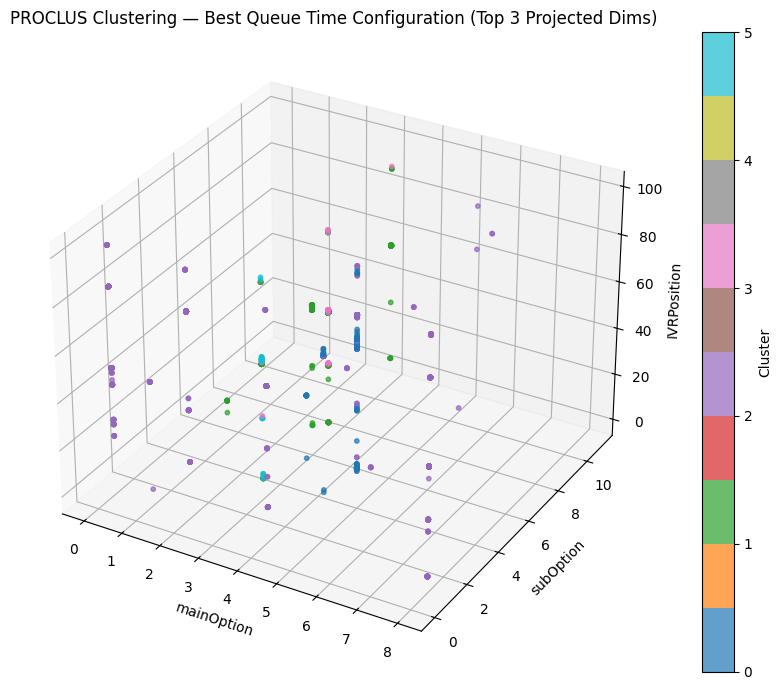

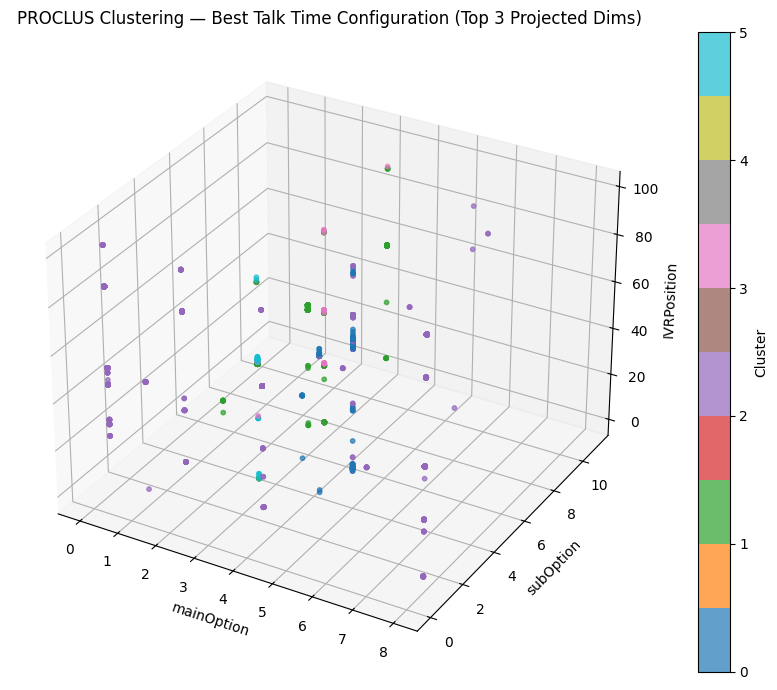

In [14]:
# ===============================
# 14. VISUALIZATION
# ===============================

# For visualisation we pick the 2 or 3 most commonly used dimensions
# across all clusters in the best configuration and plot on those axes.

def plot_proclus_result(encoded_data, feature_list, labels, cluster_dims, title):
    feature_arr = np.array(feature_list)

    # Count how often each dimension appears across cluster subspaces
    dim_counts = np.zeros(len(feature_list), dtype=int)
    for dims in cluster_dims:
        for d in dims:
            dim_counts[d] += 1

    top_dims = np.argsort(dim_counts)[::-1][:3]
    top_names = feature_arr[top_dims]

    X = encoded_data[list(top_names)].values

    fig = plt.figure(figsize=(10, 7))
    ax  = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X[:, 0], X[:, 1], X[:, 2],
        c=labels,
        cmap='tab10',
        s=10,
        alpha=0.7
    )

    ax.set_xlabel(top_names[0])
    ax.set_ylabel(top_names[1])
    ax.set_zlabel(top_names[2])
    ax.set_title(title)

    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.tight_layout()
    plt.show()


plot_proclus_result(
    encoded_df_no_ans,
    features_without_answered,
    queue_labels,
    queue_cdims,
    "PROCLUS Clustering — Best Queue Time Configuration (Top 3 Projected Dims)"
)

plot_proclus_result(
    encoded_df_no_ans,
    features_without_answered,
    talk_labels,
    talk_cdims,
    "PROCLUS Clustering — Best Talk Time Configuration (Top 3 Projected Dims)"
)

In [15]:
# ===============================
# 15. SAVE OUTPUT FILES
# ===============================

queue_results_with_ans.drop(columns=['Cluster_Subspaces']).to_csv("proclus_queue_time_with_isAnswered.csv",        index=False)
talk_results_with_ans.drop(columns=['Cluster_Subspaces']).to_csv( "proclus_talk_time_with_isAnswered.csv",         index=False)

queue_results_no_ans.drop(columns=['Cluster_Subspaces']).to_csv(  "proclus_queue_time_without_isAnswered.csv",     index=False)
talk_results_no_ans.drop(columns=['Cluster_Subspaces']).to_csv(   "proclus_talk_time_without_isAnswered.csv",      index=False)

queue_results_nz.drop(columns=['Cluster_Subspaces']).to_csv(      "proclus_queue_time_nonzero_no_isAnswered.csv", index=False)
talk_results_nz.drop(columns=['Cluster_Subspaces']).to_csv(       "proclus_talk_time_nonzero_no_isAnswered.csv",  index=False)

comparison.to_csv("proclus_final_comparison.csv", index=False)

print("All PROCLUS result files saved successfully.")

All PROCLUS result files saved successfully.


# Final Conclusion

- The PROCLUS-inspired analysis was successfully applied to the SLT Call Center dataset across three scenarios: with `isAnswered`, without `isAnswered`, and on the non-zero subset.

- Unlike SUBCLU which searched for a single best global subspace, PROCLUS assigns each cluster its own relevant feature subset. This allows different caller segments to be described by the dimensions that matter most for that group specifically.

- The analysis with `isAnswered` included is expected to show inflated separation — the same artefact observed in SUBCLU — because the answered/unanswered split dominates. Analysis 2 (without `isAnswered`) is the operationally relevant result.

- The non-zero subset (active calls only) provides the cleanest view of how PROCLUS partitions genuine call interactions.

- The `Silhouette` score is included as an additional cluster quality measure alongside the `Quality_Score` (separation × noise penalty) used in SUBCLU, allowing direct comparison of configurations.

- Together with the SUBCLU results, this notebook completes the subspace clustering component of the SLT Call Center analysis.